In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv("real_estate_cleaned.csv")

In [19]:
df.shape

(14223, 12)

In [20]:
df.head()

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,society,company_name,flat_type
0,10700000.0,under construction,1138,9450.0,2 bhk apartment in m3m antalya hills phase i,sector 79,home,True,2.0,m3m antalya hills phase i,m3m,apartment
1,14400000.0,under construction,1528,9450.0,3 bhk apartment in m3m antalya hills phase i,sector 79,property in gurgaon,True,3.0,m3m antalya hills phase i,m3m,apartment
2,10700000.0,under construction,1138,9450.0,2 bhk apartment in m3m antalya hills phase i,sector 79,properties for sale in gurgaon,True,2.0,m3m antalya hills phase i,m3m,apartment
3,40000000.0,ready to move,4500,8888.0,4 bhk independent floor,sector 57,mm india pvt ltd,False,4.0,outside socity,outside,plot
4,24000000.0,under construction,1800,13333.0,3 bhk independent floor in anant raj estate plots,sector 63,mm india pvt ltd,True,3.0,anant raj estate plots,anant,floor


In [21]:
df.isnull().sum()

price            0
status           0
area             0
rate_per_sqft    0
property_type    0
locality         0
builder_name     0
rera_approval    0
bhk_count        0
society          0
company_name     0
flat_type        0
dtype: int64

In [22]:
features = [
    'area',
    'bhk_count',
    'rera_approval',
    'status',
    'flat_type'
]

X = df[features].copy()
y = df['price'].copy()

In [23]:
X['rera_approval'] = X['rera_approval'].astype(int)

In [24]:
X.shape, y.shape

((14223, 5), (14223,))

In [25]:
numerical_features = [
    'area',
    'bhk_count',
    'rera_approval'
]

categorical_features = [
    'status',
    'flat_type'
]

In [26]:
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ))
    ]
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [30]:
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

In [31]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.20),
    
    Dense(32, activation='relu'),
    Dropout(0.20),
    
    Dense(16, activation='relu'),
    
    Dense(1)
])

In [32]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [33]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [34]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 4791717307875328.0000 - mae: 39700980.0000 - val_loss: 4660382576672768.0000 - val_mae: 39791772.0000
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4790392310464512.0000 - mae: 39685132.0000 - val_loss: 4656723801407488.0000 - val_mae: 39749124.0000
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4780525159972864.0000 - mae: 39565784.0000 - val_loss: 4637798564888576.0000 - val_mae: 39524876.0000
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4747119978086400.0000 - mae: 39156260.0000 - val_loss: 4584639217795072.0000 - val_mae: 38885672.0000
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4671012083859456.0000 - mae: 38215064.0000 - val_loss: 4481635433054208.0000 - val_mae: 37616120.0000
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4539038476271616.0000 - mae: 36604156.0000 - val_loss: 4316370191777792.0000 - val_mae: 35613544.0000
Epoch 7/100
285/285 ━━

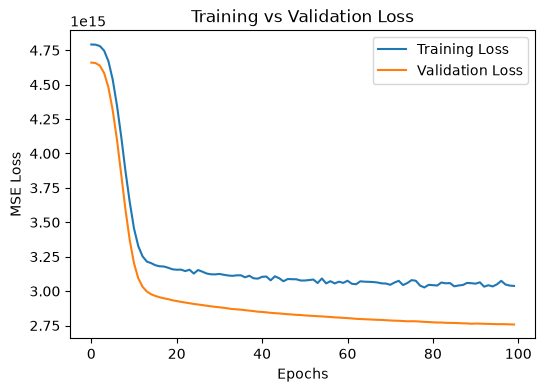

In [35]:
plt.figure(figsize=(6, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [36]:
y_pred = model.predict(X_test_processed).flatten()

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [38]:
deep_learning_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})

deep_learning_results

,Metric,Value
0,MAE,2.649967e+07
1,MSE,3.609761e+15
2,RMSE,6.008128e+07
3,R² Score,5.204590e-02


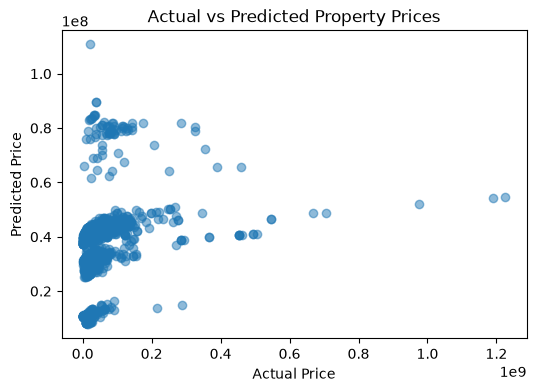

In [39]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Property Prices')

plt.show()

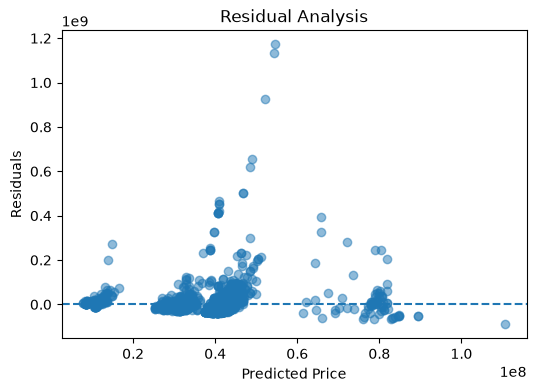

In [41]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Analysis')

plt.show()

In [42]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [43]:
improved_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.20),

    Dense(32, activation='relu'),
    Dropout(0.20),

    Dense(16, activation='relu'),

    Dense(1)
])

In [44]:
improved_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [45]:
early_stopping_improved = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [46]:
improved_history = improved_model.fit(
    X_train_processed,
    y_train_log,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_improved],
    verbose=1
)

Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 109.0727 - mae: 6.7357 - val_loss: 18.6102 - val_mae: 2.3381
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 21.5075 - mae: 2.3677 - val_loss: 9.6974 - val_mae: 0.9122
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 19.1084 - mae: 2.2067 - val_loss: 6.6391 - val_mae: 0.8760
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 14.0207 - mae: 2.1520 - val_loss: 5.2955 - val_mae: 1.3279
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9.0001 - mae: 2.0635 - val_loss: 4.0333 - val_mae: 1.2448
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.4147 - mae: 2.0534 - val_loss: 1.6050 - val_mae: 0.7721
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6985 - mae: 1.9779 - val_loss: 1.5918 - val_mae: 0.8906
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.5388 - mae: 1.9363 - val_loss: 1.3493 - val_mae: 0.8963
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3

In [47]:
y_pred_log = improved_model.predict(X_test_processed).flatten()

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [48]:
y_pred_improved = np.expm1(y_pred_log)

In [49]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)
mse_improved = mean_squared_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mse_improved)
r2_improved = r2_score(y_test, y_pred_improved)

In [50]:
improved_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [
        mae_improved,
        mse_improved,
        rmse_improved,
        r2_improved
    ]
})

improved_results

,Metric,Value
0,MAE,2.526977e+07
1,MSE,3.801127e+15
2,RMSE,6.165328e+07
3,R² Score,1.791472e-03


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
).flatten()

In [53]:
final_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.20),

    Dense(32, activation='relu'),
    Dropout(0.20),

    Dense(16, activation='relu'),

    Dense(1)
])

In [54]:
final_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [55]:
final_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [56]:
final_history = final_model.fit(
    X_train_processed,
    y_train_scaled,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[final_early_stopping],
    verbose=1
)

Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.1788 - mae: 0.4354 - val_loss: 0.7298 - val_mae: 0.3439
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.2533 - mae: 0.3804 - val_loss: 0.6584 - val_mae: 0.3336
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7335 - mae: 0.3598 - val_loss: 0.6444 - val_mae: 0.3674
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7225 - mae: 0.3547 - val_loss: 0.6099 - val_mae: 0.3098
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7120 - mae: 0.3510 - val_loss: 0.5965 - val_mae: 0.3180
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7058 - mae: 0.3475 - val_loss: 0.5888 - val_mae: 0.3158
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6914 - mae: 0.3357 - val_loss: 0.5879 - val_mae: 0.3283
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6491 - mae: 0.3362 - val_loss: 0.5808 - val_mae: 0.3432
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/

In [57]:
y_pred_scaled = final_model.predict(X_test_processed).flatten()

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [58]:
y_pred_final = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

In [59]:
mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_pred_final)

In [60]:
final_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [
        mae_final,
        mse_final,
        rmse_final,
        r2_final
    ]
})

final_results

,Metric,Value
0,MAE,1.791358e+07
1,MSE,2.091006e+15
2,RMSE,4.572751e+07
3,R² Score,4.508840e-01


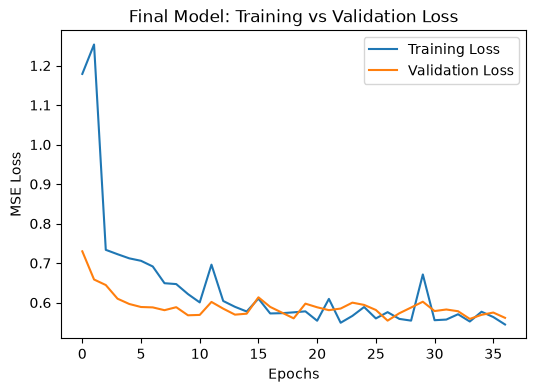

In [61]:
plt.figure(figsize=(6, 4))

plt.plot(final_history.history['loss'], label='Training Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Final Model: Training vs Validation Loss')
plt.legend()
plt.show()

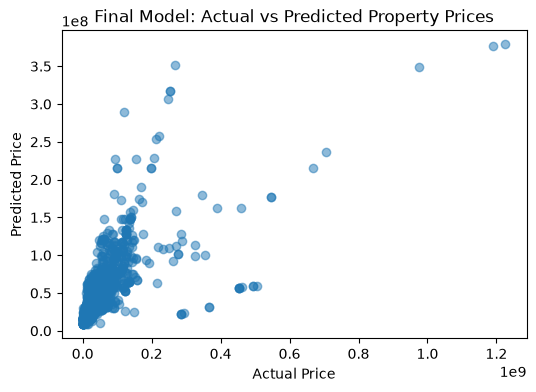

In [62]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_pred_final, alpha=0.5)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Final Model: Actual vs Predicted Property Prices')

plt.show()

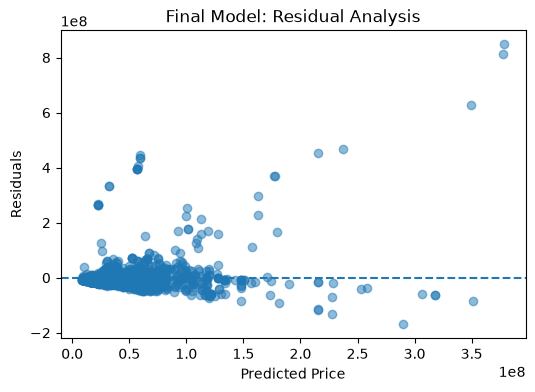

In [63]:
final_residuals = y_test - y_pred_final

plt.figure(figsize=(6, 4))

plt.scatter(y_pred_final, final_residuals, alpha=0.5)
plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Final Model: Residual Analysis')

plt.show()

In [64]:
nn_comparison = pd.DataFrame({
    'Model': [
        'Baseline Neural Network',
        'Log-Transformed Neural Network',
        'Scaled-Target Neural Network'
    ],
    'MAE': [
        mae,
        mae_improved,
        mae_final
    ],
    'RMSE': [
        rmse,
        rmse_improved,
        rmse_final
    ],
    'R² Score (%)': [
        r2 * 100,
        r2_improved * 100,
        r2_final * 100
    ]
})

nn_comparison

,Model,MAE,RMSE,R² Score (%)
0,Baseline Neural Network,2.649967e+07,6.008128e+07,5.204590
1,Log-Transformed Neural Network,2.526977e+07,6.165328e+07,0.179147
2,Scaled-Target Neural Network,1.791358e+07,4.572751e+07,45.088401


In [65]:
prediction_results = X_test.copy()

prediction_results['actual_price'] = y_test.values
prediction_results['predicted_price'] = y_pred_final
prediction_results['residual'] = y_test.values - y_pred_final

prediction_results.head()

,area,bhk_count,rera_approval,status,flat_type,actual_price,predicted_price,residual
7887,1531,4.0,1,under construction,apartment,15300000.0,40745748.0,-25445748.0
8216,1785,3.0,0,ready to move,apartment,12200000.0,30290708.0,-18090708.0
13947,1920,3.0,0,ready to move,apartment,11500000.0,31268500.0,-19768500.0
8141,2150,3.0,1,under construction,apartment,14200000.0,38112768.0,-23912768.0
13396,2404,3.0,0,ready to move,apartment,25900000.0,35228684.0,-9328684.0


In [66]:
prediction_results.to_csv(
    'deep_learning_predictions.csv',
    index=False
)

In [67]:
final_summary = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score', 'Test Samples'],
    'Value': [
        mae_final,
        mse_final,
        rmse_final,
        r2_final,
        len(y_test)
    ]
})

final_summary

,Metric,Value
0,MAE,1.791358e+07
1,MSE,2.091006e+15
2,RMSE,4.572751e+07
3,R² Score,4.508840e-01
4,Test Samples,2.845000e+03


In [68]:
training_history = pd.DataFrame({
    'epoch': range(1, len(final_history.history['loss']) + 1),
    'training_loss': final_history.history['loss'],
    'validation_loss': final_history.history['val_loss'],
    'training_mae': final_history.history['mae'],
    'validation_mae': final_history.history['val_mae']
})

training_history.head()

,epoch,training_loss,validation_loss,training_mae,validation_mae
0,1,1.178819,0.729795,0.435437,0.343923
1,2,1.253294,0.658449,0.380427,0.333566
2,3,0.733526,0.644440,0.359813,0.367364
3,4,0.722468,0.609883,0.354698,0.309757
4,5,0.711993,0.596469,0.351042,0.318017


In [69]:
training_history.to_csv(
    'deep_learning_training_history.csv',
    index=False
)

In [70]:
final_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,788 (26.52 KB)

In [71]:
final_summary

,Metric,Value
0,MAE,1.791358e+07
1,MSE,2.091006e+15
2,RMSE,4.572751e+07
3,R² Score,4.508840e-01
4,Test Samples,2.845000e+03
